In [89]:
import pandas as pd
import numpy as np

In [90]:
df=pd.read_csv('car_fuel_efficiency.csv')

In [91]:
df=df[['engine_displacement','horsepower', 'vehicle_weight','model_year','fuel_efficiency_mpg']]

In [92]:
df.count()

engine_displacement    9704
horsepower             8996
vehicle_weight         9704
model_year             9704
fuel_efficiency_mpg    9704
dtype: int64

In [93]:
median_horsepower=df['horsepower'].median()

In [94]:
print(median_horsepower)

149.0


In [95]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [96]:
np.random.seed(42)

In [97]:
idx=np.arange(n)
np.random.shuffle(idx)


In [100]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [101]:
def prepare_X(df_req, fillna_value):
    df_req = df_req.fillna(fillna_value)
    X = df_req.values
    return X

In [102]:
len(df_train), len(df_val), len(df_test)


(5824, 1940, 1940)

In [65]:
df_train.head(3)


,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,240,136.0,4050.512290,2006,10.304700
1,190,141.0,3195.866942,2017,13.479434
2,200,184.0,3006.164370,2017,16.190653


In [66]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [67]:
X_train = df_train.fillna(0).values


In [106]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [86]:

def prepare_X(df_req):
    df_num = df_req.copy()
    return df_num.fillna(0).values

<AxesSubplot: xlabel='fuel_efficiency_mpg', ylabel='Count'>

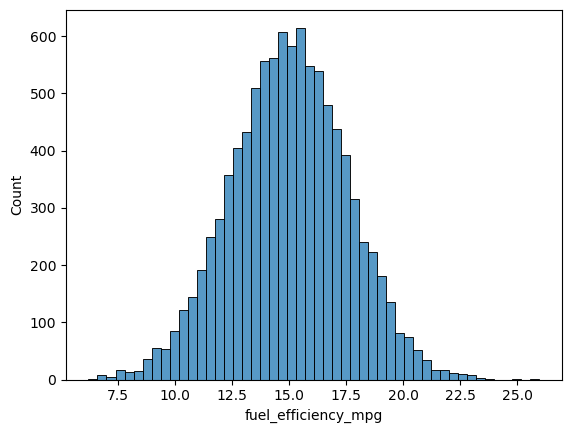

In [110]:
X_train = prepare_X(df_train, fillna_value=0)
X_val=prepare_X(df_val,fillna_value=0)
w0, w = train_linear_regression(X_train, y_train)
y_pred = w0 + X_val.dot(w)


In [111]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [112]:
rmse(y_val, y_pred)


0.5173782638823561

In [27]:
## for fill na = mean


In [115]:
X_train_2 = prepare_X(df_train, fillna_value=median_horsepower)
X_val_2=prepare_X(df_val,fillna_value=median_horsepower)

In [116]:
w0, w = train_linear_regression(X_train_2, y_train)


In [117]:
y_pred_2 = w0 + X_val_2.dot(w)

In [118]:
rmse(y_val, y_pred_2)

0.4635725479457848

In [32]:
## Regularization

In [119]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [120]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    y_pred = w0 + X_val.dot(w)
    error = rmse(y_val, y_pred)
    print(f"r={r}: RMSE={error:.10f}")


r=0: RMSE=0.5173782639
r=0.01: RMSE=0.5171115526
r=0.1: RMSE=0.5187525131
r=1: RMSE=0.5222348802
r=5: RMSE=0.5228916093
r=10: RMSE=0.5229812980
r=100: RMSE=0.5230636234


In [129]:
print(round(np.std(rmse_list),3))

0.0


In [130]:
df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)

X_full_train=df_full_train.fillna(0).values

In [131]:
y_full_train = np.concatenate([y_train, y_val])


In [132]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)


In [133]:
X_test = df_test
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)

In [136]:
rmses = []

for s in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:

    n = len(df)

    n_val = int(0.2 * n)
    n_test = int(0.2 * n)
    n_train = n - (n_val + n_test)

    idx = np.arange(n)
    np.random.seed(s)
    np.random.shuffle(idx)

    df_shuffled = df.iloc[idx]

    df_train = df_shuffled.iloc[:n_train].copy()
    df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
    df_test = df_shuffled.iloc[n_train+n_val:].copy()

    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    X_train = prepare_X(df_train,fillna_value=0) # fillna_value=0)
    w_0, w = train_linear_regression(X_train, y_train)

    X_val = prepare_X(df_val, fillna_value=0)
    y_pred = w_0 + X_val.dot(w)

    result = rmse(y_val, y_pred)
    print(s, result)

    rmses.append(result)

0 0.5206531296288427
1 0.5213388912858735
2 0.5228069974769812
3 0.5159516741209487
4 0.510912946010096
5 0.5283406460064715
6 0.5313910658153292
7 0.5090670387354352
8 0.514739912924818
9 0.5131865908277239


In [138]:
print(np.std(rmses))

0.006989446426652494
